# Statistik Data Polutan Udara dari KNIME

Notebook ini menjelaskan alur kerja KNIME dan hasil statistik data harian polutan `CO`, `NO2`, `SO2`, dan `CH4` yang diekstraksi dari database. Setiap baris pada tabel statistik mewakili satu atribut (kolom) data yang dianalisis.

## 1. Alur Kerja (Workflow) KNIME

Struktur alur kerja pada KNIME untuk membaca dan menganalisis statistik data polutan ditunjukkan pada Gambar 1:

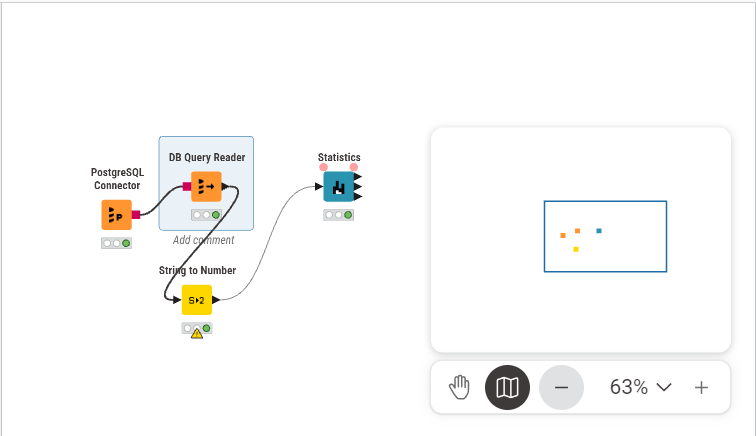

*Gambar 1. Alur kerja (workflow) KNIME: PostgreSQL Connector → DB Query Reader → String to Number → Statistics.*

**Penjelasan Node pada Workflow KNIME:**
1. **PostgreSQL Connector:** Node untuk membuat koneksi ke database PostgreSQL tempat data polutan udara disimpan.
2. **DB Query Reader:** Menjalankan query SQL untuk mengambil tabel data polutan (`Tanggal`, `NO2 (Harian)`, `CO (Harian)`, `SO2 (Harian)`, `CH4 (Harian)`) dari database.
3. **String to Number:** Mengonversi tipe data kolom polutan dari format teks (*String*) menjadi format numerik (*Number/Double*) agar dapat dihitung secara matematis.
4. **Statistics:** Menghitung ringkasan statistik deskriptif (nilai minimum, maksimum, rata-rata, standar deviasi, variansi, skewness, kurtosis, jumlah nilai *missing*, hingga visualisasi histogram) untuk setiap kolom.

---

## 2. Gambar Output Statistik KNIME

Berikut adalah tabel output statistik yang dihasilkan oleh node **Statistics** di KNIME (*Statistics Table*: 5 baris dan 16 kolom, satu baris untuk setiap atribut data):

### Tabel Statistik Utama
Gambar 2 memuat ringkasan ukuran pemusatan dan penyebaran data, yaitu Min, Max, Mean, Std. deviation, Variance, Skewness, Kurtosis, Overall sum, dan No. missings:

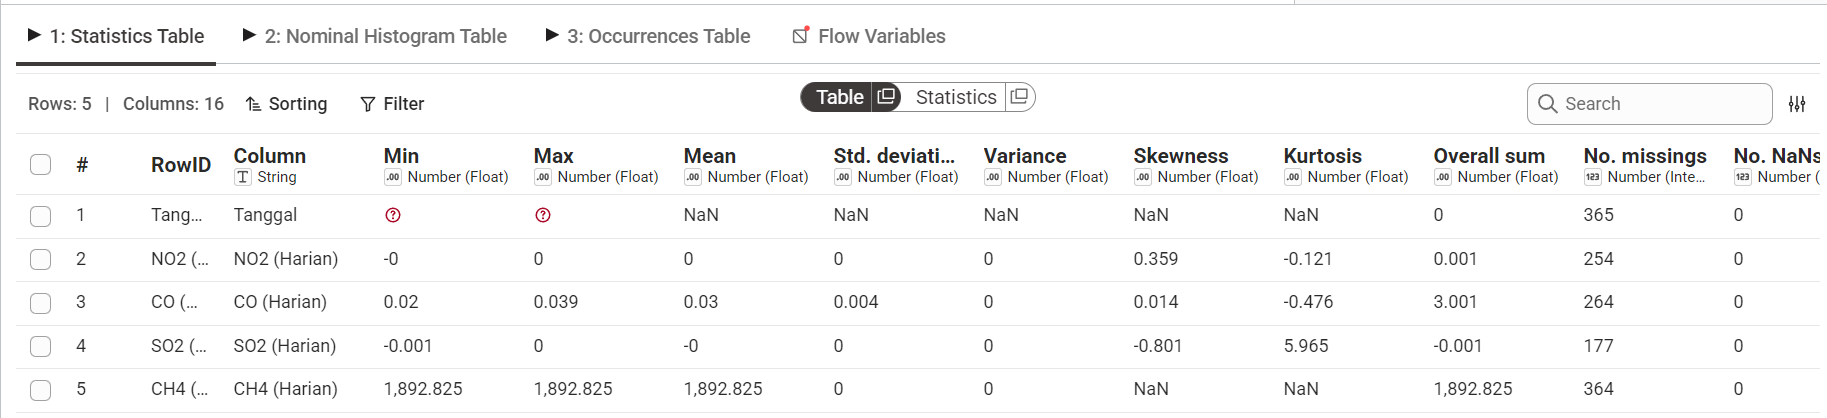

*Gambar 2. Tabel statistik utama (Statistics Table) untuk kolom `Tanggal`, `NO2 (Harian)`, `CO (Harian)`, `SO2 (Harian)`, dan `CH4 (Harian)`.*

### Tabel Statistik Lanjutan & Histogram
Gambar 3 memuat informasi nilai tak hingga (No. +∞s dan No. -∞s), median, jumlah observasi (*row count*), serta visualisasi histogram distribusi data:

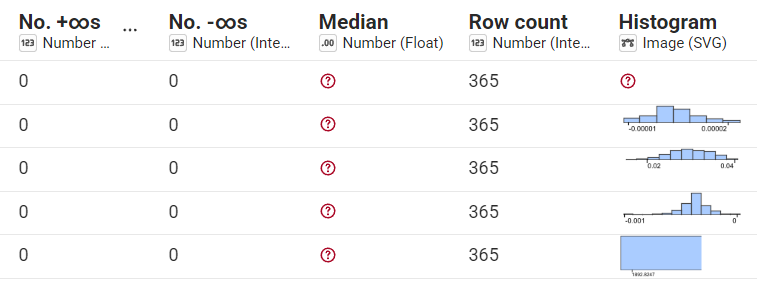

*Gambar 3. Lanjutan Statistics Table: No. +∞s, No. -∞s, Median, Row count (365 baris), dan histogram distribusi tiap kolom.*

## Penjelasan Properti Statistik

| Properti | Penjelasan | Cara menghitung / interpretasi |
|---|---|---|
| **Column** | Nama kolom atau variabel yang dianalisis, misalnya `Tanggal`, `NO2 (Harian)`, `CO (Harian)`, `SO2 (Harian)`, `CH4 (Harian)`. | Merupakan identitas variabel/kolom data. |
| **Min** | Nilai paling kecil dalam satu kolom. | $\min(x_1, x_2, \dots, x_n)$ |
| **Max** | Nilai paling besar dalam satu kolom. | $\max(x_1, x_2, \dots, x_n)$ |
| **Mean** | Nilai rata-rata seluruh data valid. | $\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$ |
| **Std. deviation** | Ukuran seberapa jauh data menyebar dari nilai rata-rata (*mean*). | Sampel: $s = \sqrt{\frac{\sum (x_i-\bar{x})^2}{n-1}}$ |
| **Variance** | Variansi atau kuadrat dari standar deviasi. | $s^2 = \frac{\sum (x_i-\bar{x})^2}{n-1}$ |
| **Skewness** | Ukuran kemencengan/asimetri distribusi data. | Nilai $>0$ menceng ke kanan, $<0$ menceng ke kiri, $\approx 0$ simetris. |
| **Kurtosis** | Ukuran keruncingan puncak dan ketebalan ekor (*tail*) distribusi data. | Nilai tinggi menunjukkan adanya pencilan/ekor tebal (*heavy tail*). |
| **Overall sum** | Jumlah total seluruh nilai valid pada kolom. | $\sum_{i=1}^{n} x_i$ |
| **No. missings** | Jumlah nilai yang kosong atau tidak terdefinisi (*NaN/Null*). | Menghitung sel yang tidak memiliki nilai (misal akibat tutupan awan satelit). |
| **No. NaNs** | Jumlah nilai `NaN` spesifik yang terdeteksi. | Pada tabel KNIME bernilai 0 karena nilai kosong telah tercatat pada `No. missings`. |
| **No. +∞s** | Jumlah nilai positif tak hingga ($+\infty$). | Menghitung observasi bernilai $+\infty$. |
| **No. -∞s** | Jumlah nilai negatif tak hingga ($-\infty$). | Menghitung observasi bernilai $-\infty$. |
| **Median** | Nilai tengah setelah data diurutkan dari terkecil ke terbesar. | Nilai pada posisi ke-$\frac{n+1}{2}$ (ganjil) atau rata-rata 2 nilai tengah (genap). |
| **Row count** | Jumlah total baris/observasi pada tabel data. | Banyaknya seluruh baris data (365 hari). |
| **Histogram** | Grafik batang frekuensi sebaran nilai dalam interval tertentu (*bin*). | Menunjukkan bentuk sebaran, pemusatan, dan pola pencilan polutan. |

---

### Analisis Data Berdasarkan Gambar Output KNIME

Berdasarkan tabel output pada Gambar 2 dan Gambar 3:

1. **Jumlah Baris (`Row count`):**
   * Semua baris memiliki `Row count = 365`, yang mencakup 365 observasi harian.
   * Meskipun setiap kolom memiliki 365 baris, sebagian besar nilainya kosong (*missing*). Jumlah data valid = `Row count` $-$ `No. missings`.
2. **Karakteristik Tiap Kolom Polutan:**
   * **`CO (Harian)` (Karbon Monoksida):**
     * $\text{Min} = 0.02$, $\text{Max} = 0.039$, $\text{Mean} = 0.03$, $\text{Std. deviation} = 0.004$, $\text{Variance} = 0$ (tampil 0 karena pembulatan; nilai sebenarnya sekitar $0.004^2 \approx 1.6 \times 10^{-5}$).
     * $\text{Skewness} = 0.014$ (hampir simetris sempurna), $\text{Kurtosis} = -0.476$ (distribusi relatif datar/platykurtic).
     * $\text{Overall sum} = 3.001$, $\text{No. missings} = 264$ ($\approx 72.3\%$ dari 365 baris), sehingga terdapat $101$ data valid.
   * **`NO2 (Harian)` (Nitrogen Dioksida):**
     * $\text{Min} = -0$, $\text{Max} = 0$, $\text{Mean} = 0$, $\text{Std. deviation} = 0$, $\text{Variance} = 0$. Nilainya sangat kecil sehingga dibulatkan menjadi 0 oleh KNIME; sumbu histogram berkisar sekitar $-0.00001$ hingga $0.00002$, sehingga nilai aslinya berada pada orde $10^{-5}$.
     * $\text{Skewness} = 0.359$ (ekor condong ke kanan), $\text{Kurtosis} = -0.121$ (mendekati distribusi normal).
     * $\text{Overall sum} = 0.001$, $\text{No. missings} = 254$ ($\approx 69.6\%$), sehingga terdapat $111$ data valid.
   * **`SO2 (Harian)` (Sulfur Dioksida):**
     * $\text{Min} = -0.001$, $\text{Max} = 0$, $\text{Mean} = -0$, $\text{Std. deviation} = 0$, $\text{Variance} = 0$.
     * $\text{Skewness} = -0.801$ (ekor condong ke kiri), $\text{Kurtosis} = 5.965$ (leptokurtic, puncak tajam dengan ekor tebal/pencilan). Pada histogram, sebagian besar data menumpuk di dekat 0 dengan ekor memanjang ke sisi negatif.
     * $\text{Overall sum} = -0.001$, $\text{No. missings} = 177$ ($\approx 48.5\%$), sehingga terdapat $188$ data valid.
   * **`CH4 (Harian)` (Metana):**
     * $\text{Min} = 1,892.825$, $\text{Max} = 1,892.825$, $\text{Mean} = 1,892.825$, $\text{Std. deviation} = 0$, $\text{Variance} = 0$.
     * $\text{Skewness} = \text{NaN}$, $\text{Kurtosis} = \text{NaN}$ (karena hanya terdapat 1 data observasi valid). Histogram hanya berupa satu batang dengan label sumbu $1892.8247$.
     * $\text{Overall sum} = 1,892.825$, $\text{No. missings} = 364$ ($\approx 99.7\%$), sehingga terdapat $1$ data valid.
   * **`Tanggal`:**
     * Merupakan kolom tanggal/waktu non-numerik, sehingga statistik numeriknya tidak dapat dihitung: $\text{Min}$ dan $\text{Max}$ ditandai ikon tanda tanya merah, sedangkan $\text{Mean}$, $\text{Std. deviation}$, $\text{Variance}$, $\text{Skewness}$, dan $\text{Kurtosis}$ bernilai `NaN`. $\text{Overall sum} = 0$ dan $\text{No. missings} = 365$.
3. **Simbol Tanda Tanya (`?`):**
   * Pada kolom **Median**, seluruh baris bernilai `?` (ikon tanda tanya merah), yang berarti median tidak dihitung/bernilai *missing*. Hal ini kemungkinan karena opsi perhitungan median pada konfigurasi node Statistics KNIME tidak diaktifkan (perhitungan median membutuhkan komputasi lebih besar).
   * Pada baris `Tanggal`, tanda `?` juga muncul pada **Min**, **Max**, dan **Histogram** karena kolom tersebut bukan tipe numerik kontinu.

## Contoh Perhitungan Manual

Gunakan data sederhana berikut:

$$x = [5, 10, 15, 20, 25]$$

Jumlah data adalah $n=5$.

### 1. Mean

$$\bar{x} = \frac{5+10+15+20+25}{5} = \frac{75}{5} = 15$$

Jadi, **mean = 15**.

### 2. Median

Data sudah terurut dan memiliki lima nilai. Nilai yang berada di posisi tengah adalah `15`, sehingga **median = 15**.

Untuk jumlah data genap, misalnya `[5, 10, 20, 25]`, median dihitung sebagai:

$$\frac{10+20}{2}=15$$

### 3. Min dan Max

- **Min** adalah nilai terkecil: `5`.
- **Max** adalah nilai terbesar: `25`.

### 4. Overall Sum

$$5+10+15+20+25=75$$

Jadi, **Overall Sum = 75**.

### 5. Variance dan Std. Dev.

Mean data adalah `15`. Selisih kuadrat dari mean:

$$
(5-15)^2 + (10-15)^2 + (15-15)^2 + (20-15)^2 + (25-15)^2
= 100+25+0+25+100=250
$$

Untuk **sample variance**:

$$s^2=\frac{250}{5-1}=62.5$$

Standar deviasi:

$$s=\sqrt{62.5}\approx 7.906$$

Catatan: jika KNIME menggunakan formula populasi, pembagi yang digunakan adalah $n$, bukan $n-1$. Karena itu hasil standar deviasi dapat berbeda sedikit dari perhitungan sampel.

### 6. Missing, NaN, dan Infinity

Jika data adalah `[5, 10, NaN, 20, 25]`, maka jumlah data missing atau `NaN` adalah `1`. Jika data memiliki `[5, 10, +∞, 20, -∞]`, maka:

- **No. +∞ = 1**
- **No. -∞ = 1**
- Nilai infinity sebaiknya dikeluarkan dari perhitungan mean, median, min, max, dan standar deviasi.

### 7. Skewness dan Kurtosis

Skewness dan kurtosis menggunakan momen distribusi. Keduanya lebih mudah dihitung dengan fungsi statistik karena memiliki beberapa definisi, terutama perbedaan antara versi populasi, sampel, dan excess kurtosis.

- Skewness mendekati `0`: data relatif simetris.
- Skewness positif: ekor distribusi lebih panjang ke kanan.
- Skewness negatif: ekor distribusi lebih panjang ke kiri.
- Kurtosis tinggi: distribusi memiliki ekor atau pencilan yang lebih kuat.
- Kurtosis negatif pada versi excess: distribusi lebih datar dibanding distribusi normal.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

# Contoh data yang digunakan untuk memeriksa rumus statistik
contoh_data = pd.Series([5, 10, 15, 20, 25], name='Contoh')
std_dev = contoh_data.std(ddof=1)

hasil_statistik = pd.DataFrame({
    'Property': [
        'Min', 'Mean', 'Median', 'Max', 'Std. Dev.', 'Variance',
        'Skewness', 'Kurtosis', 'Overall Sum', 'No. Missing',
        'No. +unlimited', 'No. -unlimited', 'Row count'
    ],
    'Value': [
        contoh_data.min(),
        contoh_data.mean(),
        contoh_data.median(),
        contoh_data.max(),
        std_dev,
        std_dev ** 2,
        contoh_data.skew(),
        contoh_data.kurt(),
        contoh_data.sum(),
        contoh_data.isna().sum(),
        np.isposinf(contoh_data).sum(),
        np.isneginf(contoh_data).sum(),
        contoh_data.size
    ]
})

print('Data contoh:', contoh_data.to_list())
print('\nHasil perhitungan:')
display(hasil_statistik)


Data contoh: [5, 10, 15, 20, 25]

Hasil perhitungan:


,Property,Value
0,Min,5.000000
1,Mean,15.000000
2,Median,15.000000
3,Max,25.000000
4,Std. Dev.,7.905694
5,Variance,62.500000
6,Skewness,0.000000
7,Kurtosis,-1.200000
8,Overall Sum,75.000000
9,No. Missing,0.000000
